# Forward sintético + ruido + misfit

Este notebook hace un ejemplo end-to-end con la implementación física nueva:
1. Lee `input.ctl`.
2. Construye el modelo con los valores medios de los 7 parámetros de inversión.
3. Aplica el mapeo elíptico físico y calcula $M_0$ total y $M_w$.
4. Ejecuta el forward con AXITRA.
5. Genera datos observados sintéticos agregando ruido gaussiano.
6. Compara señales limpias vs ruidosas y calcula el misfit.

In [ ]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'kdellipspy').exists():
            return p
    raise FileNotFoundError('No se encontro PROJECT_ROOT con carpeta kdellipspy.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
KIN_ROOT = PROJECT_ROOT / 'Kinematic_inversion'

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from kdellipspy.config_parser import ConfigParser
from kdellipspy.forward_model import AxitraForwardModel
from kdellipspy.inversion_na import MisfitCalculator
from kdellipspy.signal_utils import build_azi_times_array

ROOT = KIN_ROOT
INPUT_CTL = ROOT / 'input.ctl'
AXITRA_DIR = PROJECT_ROOT / 'kdellipspy' / 'AXITRA2024'
OUT_DIR = ROOT / 'output' / 'synthetic_forward_example_notebook'

if not INPUT_CTL.exists():
    raise FileNotFoundError(f'No se encontro input.ctl en {INPUT_CTL}')
if not AXITRA_DIR.exists():
    raise FileNotFoundError(f'No se encontro AXITRA2024 en {AXITRA_DIR}')

OUT_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('ROOT      :', ROOT)
print('INPUT_CTL :', INPUT_CTL)
print('AXITRA_DIR:', AXITRA_DIR)
print('OUT_DIR   :', OUT_DIR)

FileNotFoundError: No se encontro Kinematic_inversion root (input.ctl + src).

In [2]:
cfg = ConfigParser(str(INPUT_CTL))
station_names = [s.name for s in cfg.stations.stations]

midpoint_model = np.array([
    0.5 * (float(p.min_val) + float(p.max_val))
    for p in cfg.inversion_params.parameters
], dtype=float)

if midpoint_model.size != 7:
    raise ValueError(f'Se esperaban 7 parametros, pero hay {midpoint_model.size}.')

print('Evento         :', cfg.source_position.event_name)
print('N estaciones   :', len(station_names))
print('Modelo medio   :', np.array2string(midpoint_model, precision=4))

Evento         : Event Copiapo 2025 INTRAPLATE
N estaciones   : 10
Modelo medio   : [7.5 7.5 1.  0.5 0.5 1.7 2. ]


In [3]:
fm = AxitraForwardModel(str(INPUT_CTL), axitra_dir=str(AXITRA_DIR))
geom = fm.build_geometry_with_ellipse_slip(midpoint_model)
m0_total, mw_total = fm.estimate_total_moment_and_mw(midpoint_model, geometry=geom)

ap = None
try:
    ap = fm.build_axitra(geom, latlon=False, freesurface=True)
    ap = fm.green(ap, quiet=True)
    time, sx, sy, sz = fm.conv(ap, geom, source_type=1, t0=float(cfg.ellipse.t0), quiet=True)
finally:
    if ap is not None:
        try:
            ap.clean()
        except Exception:
            pass

time = np.asarray(time, dtype=float)
clean = np.array([sx, sy, sz], dtype=float)
clean = np.transpose(clean, (1, 2, 0))
clean = np.transpose(clean, (0, 2, 1))

print('Shape clean:', clean.shape, '(nsta, ncomp, npts)')
print('t[0], t[-1], dt:', float(time[0]), float(time[-1]), float(time[1]-time[0]) if time.size > 1 else np.nan)
print(f'M0 total [N.m]: {m0_total:.6e}')
print(f'Mw total       : {mw_total:.4f}')

Shape clean: (10, 3, 512) (nsta, ncomp, npts)
t[0], t[-1], dt: 0.0 127.75 0.25
M0 total [N.m]: 1.562353e+19
Mw total       : 6.7292


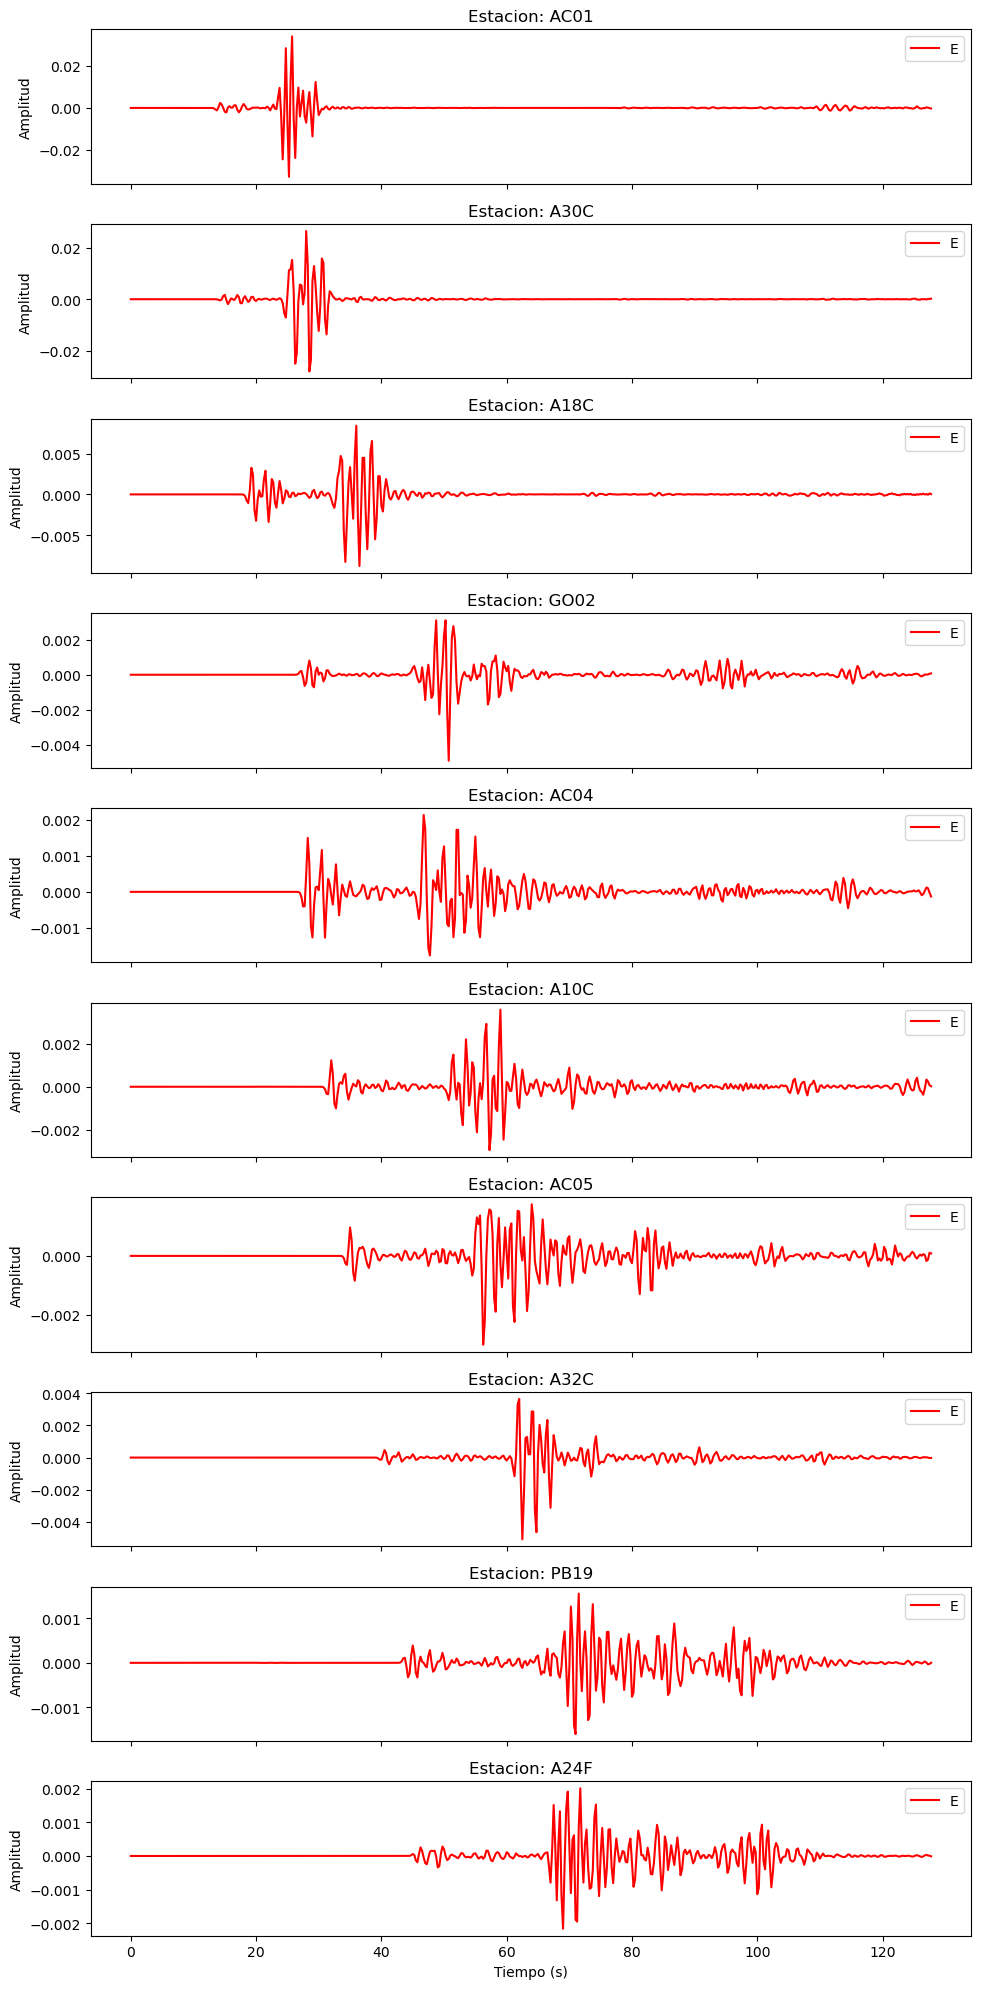

In [5]:
# Graficar las señales sintéticas
fig, axes = plt.subplots(len(station_names), 1, figsize=(10, 2 * len(station_names)), sharex=True)
if len(station_names) == 1:
    axes = [axes]
for i, (name, ax) in enumerate(zip(station_names, axes)):
    ax.plot(time, clean[i, 0], label='E', color='r')
    # ax.plot(time, clean[i, 1], label='N', color='g')
    # ax.plot(time, clean[i, 2], label='Z', color='b')
    ax.set_title(f'Estacion: {name}')
    ax.set_ylabel('Amplitud')
    ax.legend()
axes[-1].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.show()

In [8]:
NOISE_RATIO = 0.3
SEED = 20260420

rng = np.random.default_rng(SEED)
rms = float(np.sqrt(np.mean(clean ** 2)))
noise_std = max(rms * NOISE_RATIO, 1e-14)
observed_noisy = clean + noise_std * rng.standard_normal(clean.shape)

azi_times = build_azi_times_array(input_ctl_path=INPUT_CTL)
misfit_calc = MisfitCalculator(
    observed_waveforms=observed_noisy,
    time_array=time,
    azi_times_array=azi_times,
    time_window_s=20.0,
)
misfit = float(misfit_calc.l2_misfit(clean))
diag_text = misfit_calc.diagnostics_summary(clean, max_stations=3)

print(f'Noise ratio        : {NOISE_RATIO:.4f}')
print(f'Noise std global   : {noise_std:.6e}')
print(f'Misfit (clean/noisy): {misfit:.6e}')
print('\n--- Diagnostics ---')
print(diag_text)

Noise ratio        : 0.3000
Noise std global   : 3.189970e-04
Misfit (clean/noisy): 1.602521e-02

--- Diagnostics ---
[MISFIT DIAG] rms_global(obs)=1.112e-03 rms_global(syn)=1.063e-03 syn/obs=9.563e-01
[MISFIT DIAG] sta=01 P(R): obs=8.990e-03 syn=9.018e-03 | P(Z): obs=4.909e-03 syn=4.879e-03 | S(T): obs=1.383e-03 syn=1.351e-03
[MISFIT DIAG] sta=02 P(R): obs=5.756e-03 syn=5.712e-03 | P(Z): obs=3.208e-03 syn=3.260e-03 | S(T): obs=5.651e-03 syn=5.549e-03
[MISFIT DIAG] sta=03 P(R): obs=1.759e-03 syn=1.776e-03 | P(Z): obs=1.504e-03 syn=1.489e-03 | S(T): obs=2.445e-03 syn=2.434e-03
[MISFIT DIAG] window_energy(obs)=1.597e-02 window_energy(syn)=1.570e-02 syn/obs=9.829e-01


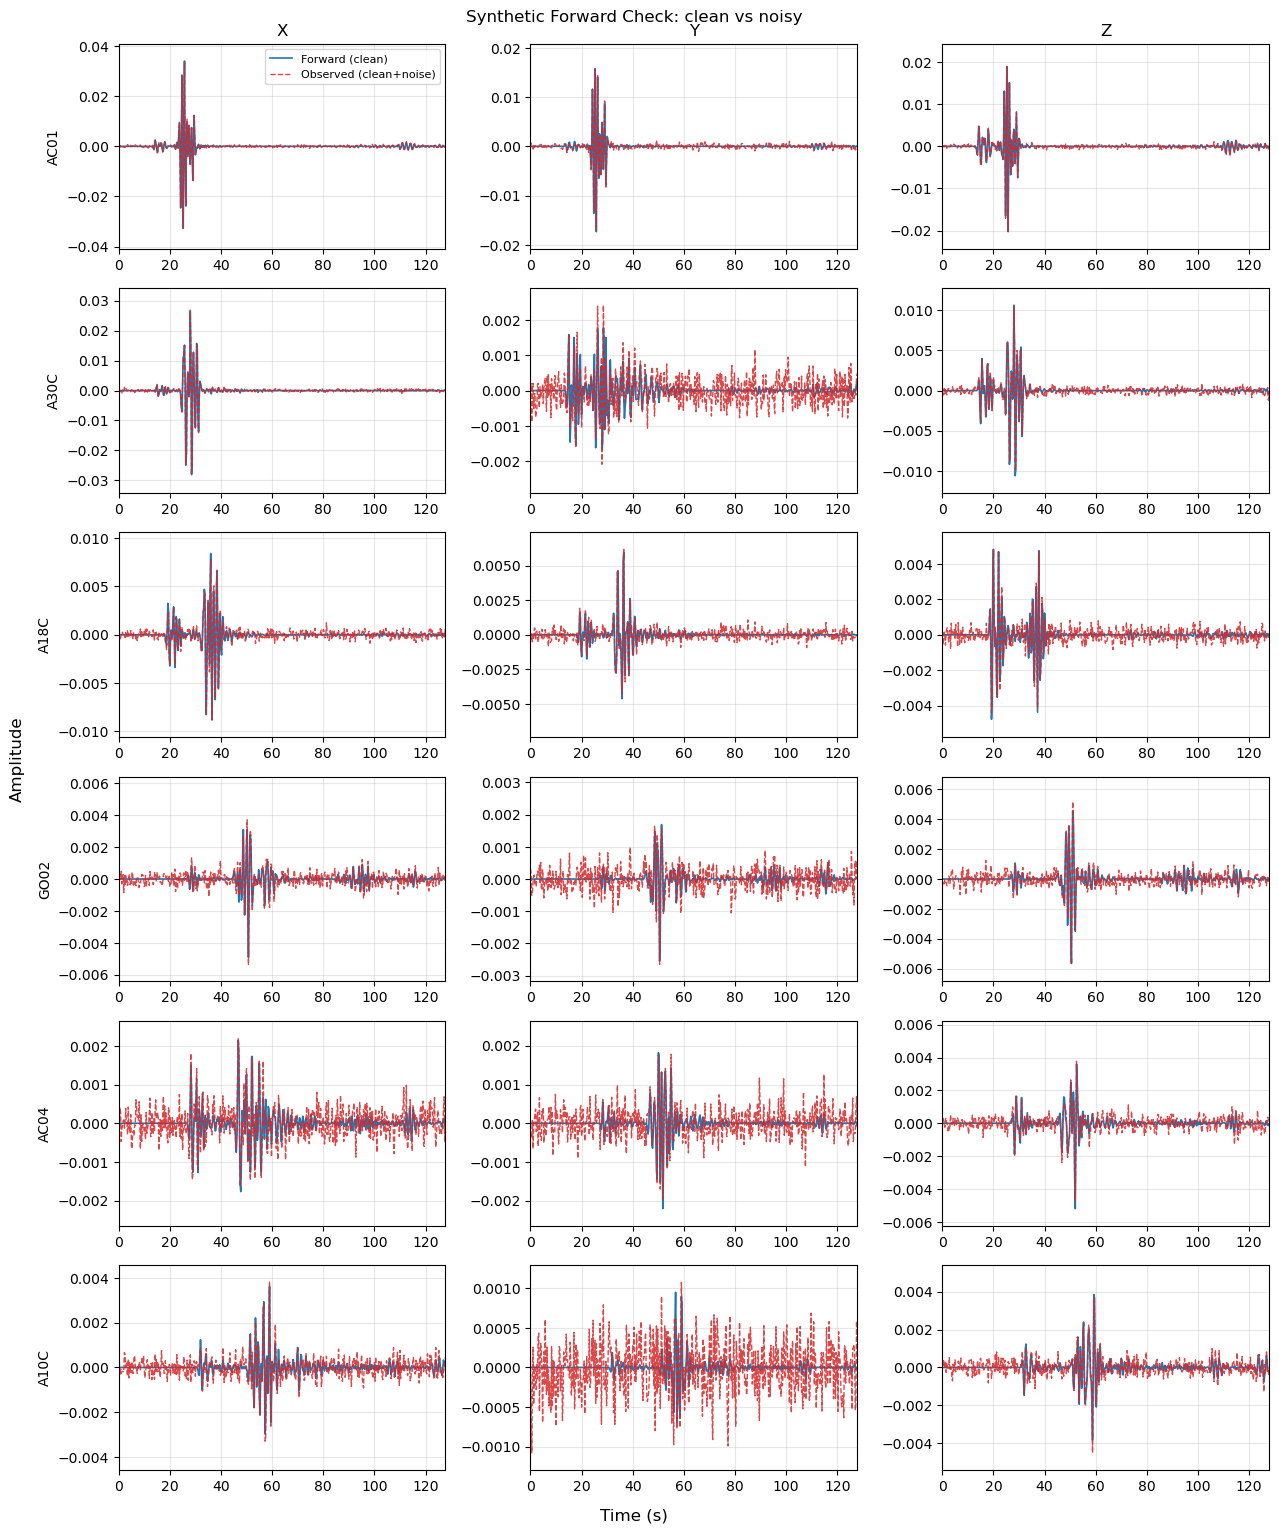

Figura guardada en: /home/alex/elliptical-rupture-updated/Kinematic_inversion/output/synthetic_forward_example_notebook/synthetic_forward_comparison.png


In [9]:
MAX_STATIONS_PLOT = 6
nsta = clean.shape[0]
nsel = min(MAX_STATIONS_PLOT, nsta)

comp_names = ['X', 'Y', 'Z']
fig, axes = plt.subplots(nsel, 3, figsize=(13, 2.6 * nsel), squeeze=False)

for i in range(nsel):
    sta_name = station_names[i] if i < len(station_names) else f'STA_{i+1:02d}'
    for icomp, comp_name in enumerate(comp_names):
        ax = axes[i][icomp]
        y_clean = clean[i, icomp, :]
        y_noisy = observed_noisy[i, icomp, :]
        peak = float(max(np.max(np.abs(y_clean)), np.max(np.abs(y_noisy)), 1e-12))

        ax.plot(time, y_clean, color='tab:blue', lw=1.2, label='Forward (clean)')
        ax.plot(time, y_noisy, color='tab:red',linestyle='--', lw=1.0, alpha=0.85, label='Observed (clean+noise)')
        ax.set_xlim(float(time[0]), float(time[-1]))
        ax.set_ylim(-1.2 * peak, 1.2 * peak)
        ax.grid(True, alpha=0.3)

        if i == 0:
            ax.set_title(comp_name)
        if icomp == 0:
            ax.set_ylabel(sta_name)
        if i == 0 and icomp == 0:
            ax.legend(loc='upper right', fontsize=8)

fig.suptitle('Synthetic Forward Check: clean vs noisy')
fig.supxlabel('Time (s)')
fig.supylabel('Amplitude')
fig.tight_layout()

fig_path = OUT_DIR / 'synthetic_forward_comparison.png'
fig.savefig(fig_path, dpi=180)
plt.show()

print('Figura guardada en:', fig_path)

In [ ]:
npz_path = OUT_DIR / 'synthetic_forward_example.npz'
txt_path = OUT_DIR / 'synthetic_forward_summary.txt'

np.savez_compressed(
    npz_path,
    time=time,
    clean=clean,
    observed_noisy=observed_noisy,
    model=midpoint_model,
    azi_times=azi_times,
    misfit=np.array([misfit], dtype=float),
    m0_total=np.array([m0_total], dtype=float),
    mw_total=np.array([mw_total], dtype=float),
)

with txt_path.open('w', encoding='utf-8') as f:
    f.write('Synthetic forward example summary\n')
    f.write('=' * 72 + '\n')
    f.write(f'Event: {cfg.source_position.event_name}\n')
    f.write(f'Stations: {len(station_names)}\n')
    f.write(f'Noise ratio: {NOISE_RATIO:.4f}\n')
    f.write(f'Noise std (global): {noise_std:.6e}\n')
    f.write(f'Misfit (clean vs noisy-observed): {misfit:.6e}\n')
    f.write(f'M0 total [N.m]: {m0_total:.6e}\n')
    f.write(f'Mw total: {mw_total:.4f}\n')
    f.write('Midpoint model (a1,a2,theta,np,tp,dmax,vr):\n')
    f.write('  ' + ', '.join(f'{v:.6f}' for v in midpoint_model) + '\n')
    f.write('\nMisfit diagnostics:\n')
    f.write(diag_text + '\n')

print('Guardado:', npz_path)
print('Guardado:', txt_path)